In [56]:
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [58]:
df = order_items.merge(
    orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date']],
    on='order_id',
    how='left'
)

df = df.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [59]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [60]:
df['tempo_entrega'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df = df[df['tempo_entrega'].notna()]
df = df[df['tempo_entrega'] > 0]

In [61]:
nordeste = ['BA','PE','CE','RN','PB','AL','SE','MA','PI']

df_ne = df[df['customer_state'].isin(nordeste)]

In [62]:
tempo_ne = df_ne.groupby('customer_state')['tempo_entrega'].mean()

In [63]:
pedidos_ne = df_ne.groupby('customer_state')['order_id'].nunique()

In [64]:
analise_ne = pd.concat([tempo_ne, pedidos_ne], axis=1)
analise_ne.columns = ['tempo_medio', 'qtd_pedidos']

analise_ne = analise_ne.sort_values(by='tempo_medio', ascending=False)

**Tempo Médio de Entrega / Volume de Pedidos - Nordeste**


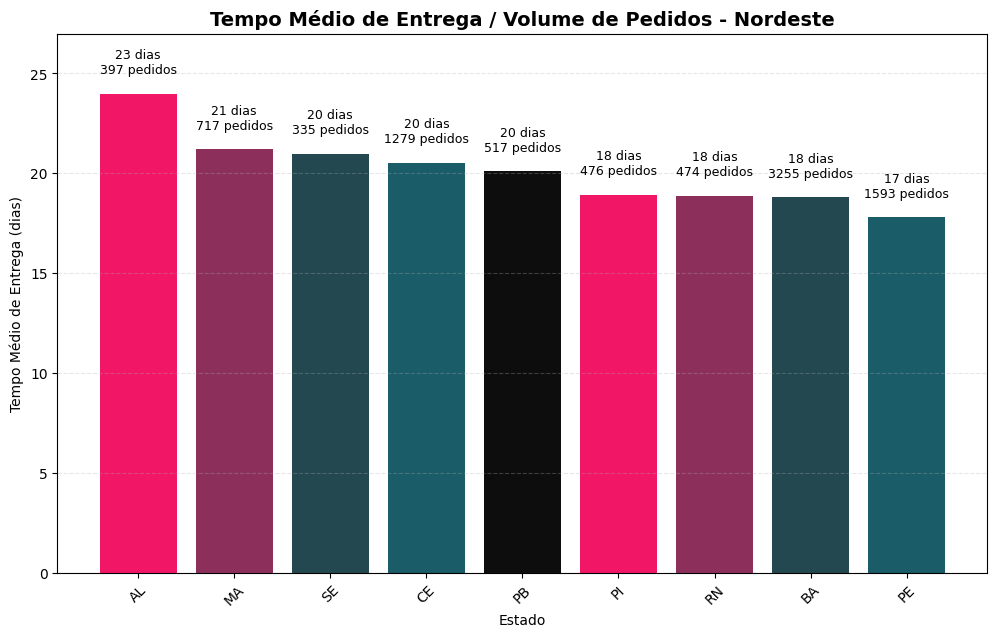

In [100]:
plt.figure(figsize=(12,7))

bars = plt.bar(
    analise_ne.index,
    analise_ne['tempo_medio'],
    color= cores_fiap[:len(analise_ne)]
)

plt.title('Tempo Médio de Entrega / Volume de Pedidos - Nordeste', fontsize=14, weight='bold')
plt.xlabel('Estado')
plt.ylabel('Tempo Médio de Entrega (dias)')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.ylim(0, analise_ne['tempo_medio'].max() + 3)

for i, v in enumerate(analise_ne['tempo_medio']):
    pedidos = analise_ne['qtd_pedidos'].iloc[i]
    plt.text(
        i,
        v + 1.0,
        f'{int(v)} dias\n{pedidos} pedidos',
        ha='center',
        color='black',
        fontsize=9
    )

plt.show()

In [66]:
regioes = {
    'SP':'Sudeste','RJ':'Sudeste','MG':'Sudeste','ES':'Sudeste',
    'RS':'Sul','SC':'Sul','PR':'Sul',
    'BA':'Nordeste','PE':'Nordeste','CE':'Nordeste','RN':'Nordeste','PB':'Nordeste','AL':'Nordeste','SE':'Nordeste','MA':'Nordeste','PI':'Nordeste',
    'GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste','DF':'Centro-Oeste',
    'AM':'Norte','PA':'Norte','AC':'Norte','RO':'Norte','RR':'Norte','AP':'Norte','TO':'Norte'
}

df['regiao'] = df['customer_state'].map(regioes)

In [67]:
df['regiao'] = df['customer_state'].map(regioes)
tempo_regiao = df.groupby('regiao')['tempo_entrega'].mean()
pedidos_regiao = df.groupby('regiao')['order_id'].nunique()

analise_regiao = pd.concat([tempo_regiao, pedidos_regiao], axis=1)
analise_regiao.columns = ['tempo_medio', 'qtd_pedidos']

analise_regiao = analise_regiao.sort_values(by='tempo_medio', ascending=False)

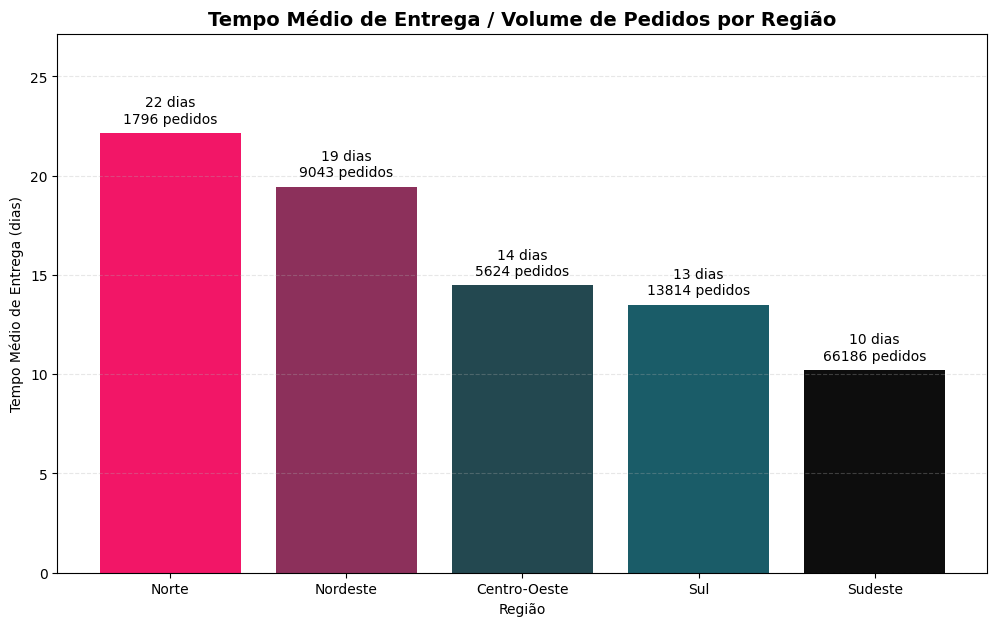

In [121]:
cores_fiap = ['#F21667','#8C305B','#234850','#1A5C68','#0D0D0D']

plt.figure(figsize=(12,7))

plt.bar(
    analise_regiao.index,
    analise_regiao['tempo_medio'],
    color=cores_fiap[:len(analise_regiao)]
)

plt.title('Tempo Médio de Entrega / Volume de Pedidos por Região', fontsize=14, weight='bold')
plt.xlabel('Região')
plt.ylabel('Tempo Médio de Entrega (dias)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(analise_regiao['tempo_medio']):
    pedidos = analise_regiao['qtd_pedidos'].iloc[i]
    plt.text(
        i,
        v + 0.5,
        f'{int(v)} dias\n{pedidos} pedidos',
        ha='center',
        color='black'
    )
    plt.ylim(0, analise_regiao['tempo_medio'].max() + 5)

plt.show()